# Isolation Forest IDS — Healthcare IoT Data **with sequence augmentation**

## 0) Setup

In [1]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from joblib import dump

np.random.seed(42)

## 1) Load Kaggle dataset

In [2]:
DATA_DIR = "/kaggle/input/datasets/ziya07/healthcare-iot-data/"
csvs = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if len(csvs) == 0:
    csvs = glob.glob("*.csv")
assert len(csvs) > 0, "No CSV found. add the dataset to the notebook."
DATA_PATH = csvs[0]
print("Using:", DATA_PATH)

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

Using: /kaggle/input/datasets/ziya07/healthcare-iot-data/healthcare_iot_target_dataset.csv


,Patient_ID,Timestamp,Sensor_ID,Sensor_Type,Temperature (°C),Systolic_BP (mmHg),Diastolic_BP (mmHg),Heart_Rate (bpm),Device_Battery_Level (%),Target_Blood_Pressure,Target_Heart_Rate,Target_Health_Status,Battery_Level (%)
0,8270,2024-01-01 00:00:00,4,Temperature,36.8,150.0,95.0,84.0,99,140.0,90.0,Unhealthy,80
1,1860,2024-01-01 01:00:00,1,Battery,37.3,150.0,95.0,77.0,84,140.0,90.0,Unhealthy,94
2,6390,2024-01-01 02:00:00,1,Temperature,36.5,140.0,85.0,99.0,93,130.0,80.0,Healthy,84
3,6191,2024-01-01 03:00:00,4,Battery,37.3,120.0,80.0,67.0,95,150.0,90.0,Unhealthy,92
4,6734,2024-01-01 04:00:00,4,Temperature,36.8,90.0,60.0,98.0,97,120.0,80.0,Unhealthy,87


## 2) Normalize columns + extract only what the flow can provide

In [3]:
def normalize_cols(cols):
    out=[]
    for c in cols:
        c2 = str(c)
        c2 = re.sub(r"\(.*?\)", "", c2)
        c2 = c2.strip().lower()
        c2 = re.sub(r"[^a-z0-9]+", "_", c2)
        c2 = re.sub(r"_+", "_", c2).strip("_")
        out.append(c2)
    return out

df = df_raw.copy()
df.columns = normalize_cols(df.columns)

def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_patient = pick_col(["patient_id", "patientid"])
col_ts = pick_col(["timestamp", "time", "datetime"])
col_device = pick_col(["sensor_id", "device_id", "sensorid"])
col_hr = pick_col(["heart_rate", "heartrate", "heart_rate_bpm", "heart_rate__bpm"])

assert col_patient is not None, "Patient_ID column not found"
assert col_ts is not None, "Timestamp column not found"
assert col_hr is not None, "Heart_Rate column not found"

base = pd.DataFrame({
    "patient_id": df[col_patient].astype(str),
    "timestamp": pd.to_datetime(df[col_ts], errors="coerce"),
    "device_id": df[col_device].astype(str) if col_device is not None else "HRM-ICU-01",
    "heart_rate": pd.to_numeric(df[col_hr], errors="coerce"),
})
base = base.dropna(subset=["timestamp","heart_rate"]).copy()
base["heart_rate"] = base["heart_rate"].astype(float)

print("Rows:", len(base), "| Patients:", base["patient_id"].nunique(), "| Devices:", base["device_id"].nunique())
base.head()

Rows: 200 | Patients: 199 | Devices: 4


,patient_id,timestamp,device_id,heart_rate
0,8270,2024-01-01 00:00:00,4,84.0
1,1860,2024-01-01 01:00:00,1,77.0
2,6390,2024-01-01 02:00:00,1,99.0
3,6191,2024-01-01 03:00:00,4,67.0
4,6734,2024-01-01 04:00:00,4,98.0


## 3) Why we augment into sequences (to match streaming)

The dataset is ~200 rows but ~199 patients, so we do not have per-patient time series.

Node-RED generates a stream (same patients with repeated readings every ~5 seconds).
To train a detector that works on streams, we generate **normal sequences** per patient around their baseline HR.

This is still grounded in real data because:
- baseline HR comes from the Kaggle dataset
- noise/drift magnitudes are chosen to be small and physiologically plausible


In [4]:
def make_normal_sequences(base_df, seq_len=60, period_s=5, hr_noise_sd=2.0, drift_sd=0.15):
    # For each patient row, generate seq_len points around their baseline HR
    rows=[]
    for _, r in base_df.iterrows():
        pid = r["patient_id"]
        dev = r["device_id"]
        hr0 = float(r["heart_rate"])
        t0 = pd.Timestamp(r["timestamp"])

        hr = hr0
        drift = 0.0
        for k in range(seq_len):
            drift += np.random.normal(0, drift_sd)
            hr = hr0 + drift + np.random.normal(0, hr_noise_sd)
            hr = float(np.clip(hr, 40, 180))  # plausible bound for normal-ish values
            ts = t0 + pd.Timedelta(seconds=period_s*k)

            rows.append({
                "patient_id": pid,
                "device_id": dev,
                "timestamp": ts,
                "heart_rate": hr,
                "y_true": 0,
                "tag": "normal_aug"
            })
    return pd.DataFrame(rows)

seq_len = 50  # 50 points per patient → ~10k rows max, still light
df_norm = make_normal_sequences(base, seq_len=seq_len)
df_norm.head(), len(df_norm)

(  patient_id device_id           timestamp  heart_rate  y_true         tag
 0       8270         4 2024-01-01 00:00:00   83.797979       0  normal_aug
 1       8270         4 2024-01-01 00:00:05   87.217720       0  normal_aug
 2       8270         4 2024-01-01 00:00:10   83.668263       0  normal_aug
 3       8270         4 2024-01-01 00:00:15   85.908289       0  normal_aug
 4       8270         4 2024-01-01 00:00:20   85.388118       0  normal_aug,
 10000)

### Quick visualization: one patient's augmented normal sequence

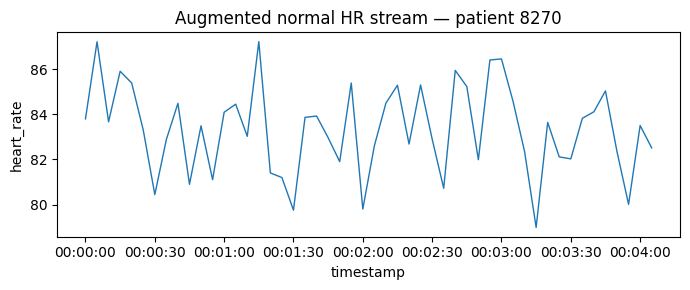

In [5]:
sample_pid = df_norm["patient_id"].iloc[0]
g = df_norm[df_norm["patient_id"]==sample_pid].sort_values("timestamp")

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(g["timestamp"], g["heart_rate"], linewidth=1)
ax.set_title(f"Augmented normal HR stream — patient {sample_pid}")
ax.set_xlabel("timestamp"); ax.set_ylabel("heart_rate")
plt.tight_layout()
plt.show()

## 4) Feature engineering

We use features that can be computed online from **only `patient_id`, `timestamp`, `heart_rate`**:

- `heart_rate`
- `hr_out_of_range` (very broad safety bounds)
- `hr_delta` (difference vs previous reading for same patient)
- `hr_abs_delta`
- `hr_roll_median` (rolling median over last `window_n` readings)
- `hr_roll_iqr` (rolling IQR over last `window_n` readings)
- `hr_z` = (HR - roll_median) / roll_iqr (robust deviation from patient's current baseline)

These are stable even if message timing is perfectly regular (as in the flow).


In [6]:
window_n = 12   # 12 readings * 5s = 60s window
warmup_n = 8    # need at least 8 readings to trust rolling stats

def add_stream_features(df_stream, window_n=12):
    df_stream = df_stream.sort_values(["patient_id","timestamp"]).copy()

    # previous HR per patient
    prev_hr = df_stream.groupby("patient_id")["heart_rate"].shift(1)
    df_stream["hr_delta"] = (df_stream["heart_rate"] - prev_hr).fillna(0.0)
    df_stream["hr_abs_delta"] = df_stream["hr_delta"].abs()

    # rolling robust stats per patient
    def rolling_median(s):
        return s.rolling(window_n, min_periods=1).median()
    def rolling_iqr(s):
        q3 = s.rolling(window_n, min_periods=1).quantile(0.75)
        q1 = s.rolling(window_n, min_periods=1).quantile(0.25)
        return (q3 - q1).clip(lower=1e-6)

    df_stream["hr_roll_median"] = df_stream.groupby("patient_id")["heart_rate"].transform(rolling_median)
    df_stream["hr_roll_iqr"] = df_stream.groupby("patient_id")["heart_rate"].transform(rolling_iqr)
    df_stream["hr_z"] = (df_stream["heart_rate"] - df_stream["hr_roll_median"]) / df_stream["hr_roll_iqr"]

    df_stream["hr_out_of_range"] = ((df_stream["heart_rate"] < 40) | (df_stream["heart_rate"] > 180)).astype(int)
    return df_stream

df_feat = add_stream_features(df_norm, window_n=window_n)
df_feat.head()

,patient_id,device_id,timestamp,heart_rate,y_true,tag,hr_delta,hr_abs_delta,hr_roll_median,hr_roll_iqr,hr_z,hr_out_of_range
3900,1064,1,2024-01-04 06:00:00,97.515183,0,normal_aug,0.000000,0.000000,97.515183,0.000001,0.000000,0
3901,1064,1,2024-01-04 06:00:05,99.139344,0,normal_aug,1.624161,1.624161,98.327263,0.812080,1.000000,0
3902,1064,1,2024-01-04 06:00:10,97.620909,0,normal_aug,-1.518435,1.518435,97.620909,0.812080,0.000000,0
3903,1064,1,2024-01-04 06:00:15,102.241825,0,normal_aug,4.620916,4.620916,98.380126,2.320487,1.664176,0
3904,1064,1,2024-01-04 06:00:20,95.196020,0,normal_aug,-7.045805,7.045805,97.620909,1.624161,-1.493010,0


### Feature list used by the model

In [7]:
feature_cols = [
    "heart_rate",
    "hr_delta",
    "hr_abs_delta",
    "hr_roll_median",
    "hr_roll_iqr",
    "hr_z",
    "hr_out_of_range",
]
feature_cols

['heart_rate',
 'hr_delta',
 'hr_abs_delta',
 'hr_roll_median',
 'hr_roll_iqr',
 'hr_z',
 'hr_out_of_range']

## 5) Create evaluation anomalies (match Node-RED Attack On)

Your flow's Attack On forces HR≈125 bpm (MITM) for PAT-001.  
So we inject anomalies that look like:
- sudden sustained HR=125 for a window
- spikes (+40..+60) or drops (-30..-50)

This is used only for calibration/testing (the model is still trained on normal).

In [8]:
def inject_attack_hr125(df_stream, target_pid, start_idx=20, length=12, hr_value=125.0):
    df = df_stream.copy()
    g_idx = df.index[df["patient_id"] == target_pid]
    if len(g_idx) < start_idx+length:
        return df
    attack_idx = g_idx[start_idx:start_idx+length]
    df.loc[attack_idx, "heart_rate"] = hr_value
    df.loc[attack_idx, "y_true"] = 1
    df.loc[attack_idx, "tag"] = "attack_hr125"
    return df

def inject_random_spikes(df_stream, frac=0.02, seed=123):
    rng = np.random.default_rng(seed)
    df = df_stream.copy()
    n = len(df)
    k = max(1, int(n*frac))
    idx = rng.choice(df.index, size=k, replace=False)
    df.loc[idx, "heart_rate"] = np.clip(df.loc[idx, "heart_rate"].values + rng.normal(50, 10, size=k), 0, 250)
    df.loc[idx, "y_true"] = 1
    df.loc[idx, "tag"] = "spike"
    return df

# Split by patients to avoid leakage (same patient streams shouldn't be in train+test)
patients = df_feat["patient_id"].unique()
rng = np.random.default_rng(42)
rng.shuffle(patients)

n_pat = len(patients)
train_p = patients[: int(0.70*n_pat)]
cal_p   = patients[int(0.70*n_pat): int(0.85*n_pat)]
test_p  = patients[int(0.85*n_pat):]

train_df = df_feat[df_feat["patient_id"].isin(train_p)].copy()
cal_df   = df_feat[df_feat["patient_id"].isin(cal_p)].copy()
test_df  = df_feat[df_feat["patient_id"].isin(test_p)].copy()

# Ensure labels exist
for d in (train_df, cal_df, test_df):
    d["y_true"] = d.get("y_true", 0)

# Inject anomalies into cal/test
cal_mix = inject_random_spikes(cal_df, frac=0.03, seed=1)
test_mix = inject_random_spikes(test_df, frac=0.03, seed=2)

# Force an hr=125 attack on one patient in cal and one in test (if exists)
if len(cal_p) > 0:
    cal_mix = inject_attack_hr125(cal_mix, target_pid=cal_p[0], start_idx=15, length=10, hr_value=125.0)
if len(test_p) > 0:
    test_mix = inject_attack_hr125(test_mix, target_pid=test_p[0], start_idx=15, length=10, hr_value=125.0)

# Recompute stream features after injection
cal_mix = add_stream_features(cal_mix, window_n=window_n)
test_mix = add_stream_features(test_mix, window_n=window_n)

print("Train rows:", len(train_df), "Cal rows:", len(cal_mix), "Test rows:", len(test_mix))
print("Cal anomaly rate:", cal_mix["y_true"].mean(), "Test anomaly rate:", test_mix["y_true"].mean())

Train rows: 7000 Cal rows: 1500 Test rows: 1500
Cal anomaly rate: 0.03666666666666667 Test anomaly rate: 0.03666666666666667


## 6) Train Isolation Forest (normal only) + threshold calibration

In [9]:
scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[feature_cols])

model = IsolationForest(
    n_estimators=600,
    max_samples=0.8,
    max_features=1.0,
    contamination=0.02,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)

def score(df_part):
    X = scaler.transform(df_part[feature_cols])
    return -model.decision_function(X)

cal_mix["anomaly_score"] = score(cal_mix)
test_mix["anomaly_score"] = score(test_mix)

# Choose threshold to maximize F1 on calibration mix (synthetic anomalies)
y_cal = cal_mix["y_true"].values
thr_candidates = np.quantile(cal_mix["anomaly_score"], np.linspace(0.80, 0.995, 180))

best=None
for thr in thr_candidates:
    y_pred = (cal_mix["anomaly_score"].values >= thr).astype(int)
    tp = ((y_pred==1) & (y_cal==1)).sum()
    fp = ((y_pred==1) & (y_cal==0)).sum()
    fn = ((y_pred==0) & (y_cal==1)).sum()
    precision = tp/(tp+fp+1e-9)
    recall = tp/(tp+fn+1e-9)
    f1 = 2*precision*recall/(precision+recall+1e-9)
    if best is None or f1>best["f1"]:
        best={"thr":float(thr),"precision":float(precision),"recall":float(recall),"f1":float(f1)}

THRESHOLD = best["thr"]
print("Best calib:", best)

Best calib: {'thr': 0.24960136342458933, 'precision': 0.9545454545237604, 'recall': 0.7636363636224794, 'f1': 0.8484848479738804}


## 7) Evaluation on test mix + visualizations

In [10]:
y_test = test_mix["y_true"].values
y_pred = (test_mix["anomaly_score"].values >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

           0     0.9938    0.9993    0.9965      1445
           1     0.9787    0.8364    0.9020        55

    accuracy                         0.9933      1500
   macro avg     0.9863    0.9178    0.9493      1500
weighted avg     0.9933    0.9933    0.9931      1500



array([[1444,    1],
       [   9,   46]])

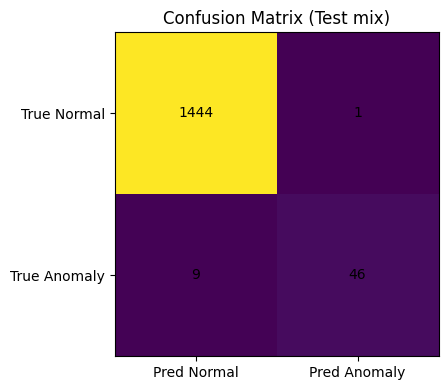

In [11]:
# Confusion matrix plot
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, interpolation="nearest")
ax.set_title("Confusion Matrix (Test mix)")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["Pred Normal","Pred Anomaly"])
ax.set_yticklabels(["True Normal","True Anomaly"])
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.show()

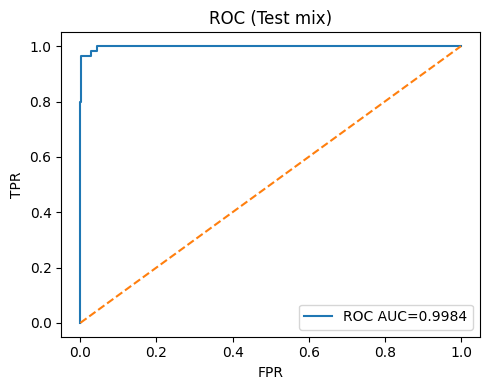

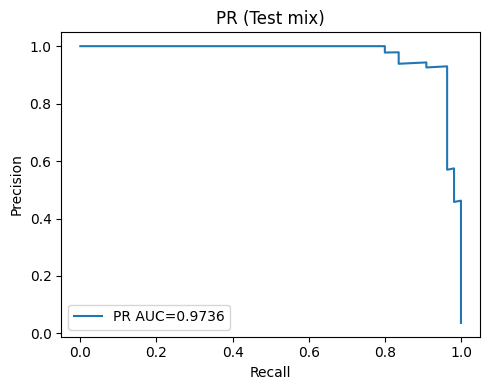

In [12]:
# ROC + PR
fpr, tpr, _ = roc_curve(y_test, test_mix["anomaly_score"].values)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(y_test, test_mix["anomaly_score"].values)
pr_auc = average_precision_score(y_test, test_mix["anomaly_score"].values)

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.4f}")
ax.plot([0,1],[0,1], linestyle="--")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC (Test mix)")
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(rec, prec, label=f"PR AUC={pr_auc:.4f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("PR (Test mix)")
ax.legend(); plt.tight_layout(); plt.show()

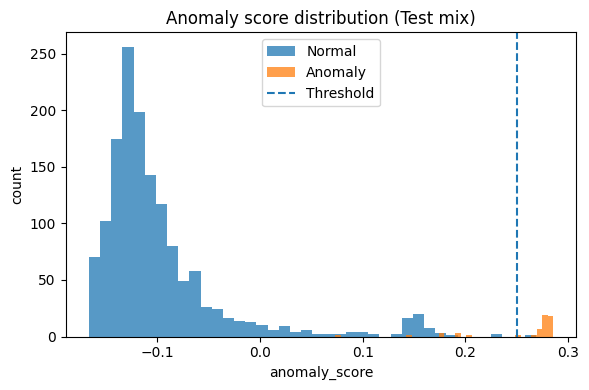

In [13]:
# Score distribution
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(test_mix.loc[test_mix["y_true"]==0,"anomaly_score"], bins=40, alpha=0.75, label="Normal")
ax.hist(test_mix.loc[test_mix["y_true"]==1,"anomaly_score"], bins=40, alpha=0.75, label="Anomaly")
ax.axvline(THRESHOLD, linestyle="--", label="Threshold")
ax.set_title("Anomaly score distribution (Test mix)")
ax.set_xlabel("anomaly_score"); ax.set_ylabel("count")
ax.legend(); plt.tight_layout(); plt.show()

### Timeline view for an attacked patient

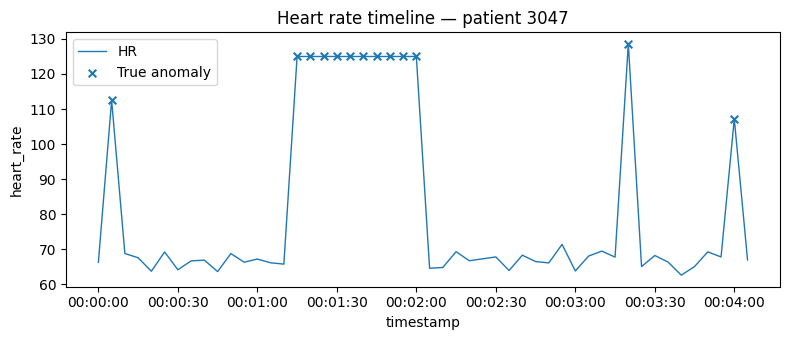

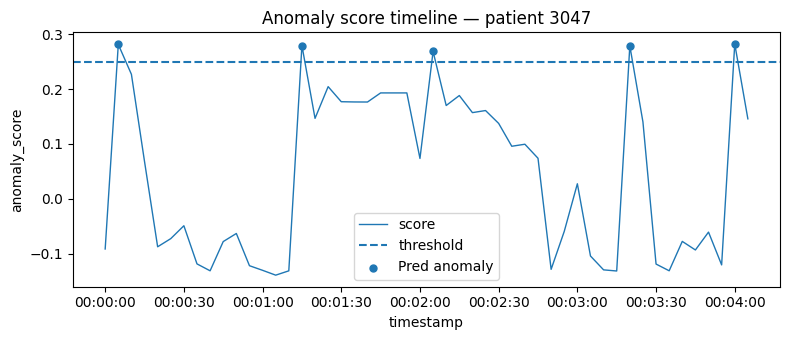

In [14]:
pid = test_p[0] if len(test_p)>0 else test_mix["patient_id"].iloc[0]
g = test_mix[test_mix["patient_id"]==pid].sort_values("timestamp").copy()
g["y_pred"] = (g["anomaly_score"] >= THRESHOLD).astype(int)

fig, ax = plt.subplots(figsize=(8,3.5))
ax.plot(g["timestamp"], g["heart_rate"], linewidth=1, label="HR")
ax.scatter(g.loc[g["y_true"]==1,"timestamp"], g.loc[g["y_true"]==1,"heart_rate"], s=30, label="True anomaly", marker="x")
ax.set_title(f"Heart rate timeline — patient {pid}")
ax.set_xlabel("timestamp"); ax.set_ylabel("heart_rate")
ax.legend(); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8,3.5))
ax.plot(g["timestamp"], g["anomaly_score"], linewidth=1, label="score")
ax.axhline(THRESHOLD, linestyle="--", label="threshold")
ax.scatter(g.loc[g["y_pred"]==1,"timestamp"], g.loc[g["y_pred"]==1,"anomaly_score"], s=25, label="Pred anomaly")
ax.set_title(f"Anomaly score timeline — patient {pid}")
ax.set_xlabel("timestamp"); ax.set_ylabel("anomaly_score")
ax.legend(); plt.tight_layout(); plt.show()

## 8) Save artifact for the MQTT IDS service

In [15]:
# global baseline derived from normal augmented data
hr_m = float(train_df["heart_rate"].median())
hr_iqr = float(train_df["heart_rate"].quantile(0.75) - train_df["heart_rate"].quantile(0.25))
hr_iqr = max(1e-6, hr_iqr)

global_baseline = {"hr_median": hr_m, "hr_iqr": hr_iqr}

os.makedirs("artifacts", exist_ok=True)
artifact = {
    "model": model,
    "scaler": scaler,
    "feature_cols": feature_cols,
    "threshold": float(THRESHOLD),
    "model_name": "isolation_forest_v3_hr_stream",
    "global_baseline": global_baseline,
    "window_n": int(window_n),
    "warmup_n": int(warmup_n),
    "period_s": 5,
}
dump(artifact, "artifacts/ids_iforest.joblib")
print("Saved artifacts/ids_iforest.joblib")

Saved artifacts/ids_iforest.joblib
